# EIS Validation and Circuit Fitting
To perform validation, we use the ZHIT method as implemented in pyimpspec.
Similarly, circuit fitting can be performed using pyimpspec.

## Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import BiologicLoader
from redoxed.plots import NyquistPlot, ResidualsPlot
from redoxed.impedance import EISData, ResidualsData

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

# Z-HIT
from pyimpspec import perform_zhit, ZHITResult, DataSet

from schemdraw import Drawing

from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
)

%matplotlib inline
# %matplotlib qt

# if think is slowing down, disable autoreload by restarting kernel without it.
# %load_ext autoreload
# %autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

## Data Loading

A dataset is shown with 3 repeats. redoxED allows these repeats to be averaged.

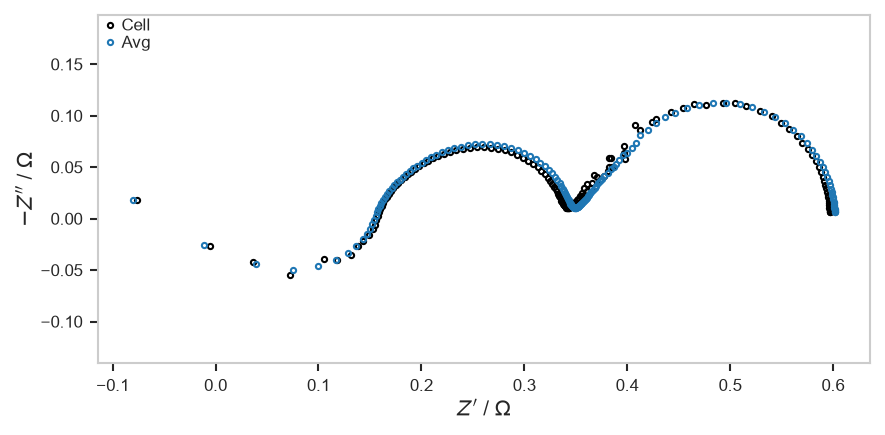

In [ ]:
# initialise plot dictionaries
eis_plot_dict = {}
residuals_plot_dict = {}
drt_plot_dict = {}

#########################
##### Data loading ######
#########################
fpath = r"../data/cell_EIS_2.mpr"

# select measurement
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 3) # select 3rd cycle EIS
EISData_object = ECData_object.to_EISData()
# EISData_object.crop_frequency(0.01, 2e5)
#EISData_object.crop_frequency(1e5, 2e5)
EISData_object.label = "Cell"
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

# create averaged spectra
ECData_object = BiologicLoader().load_data(fpath=fpath)
EISData_object = ECData_object.average_to_EISData(cycle_range=(1, 50), label="Avg")
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["blue"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }


#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
# NyquistPlot_object.ax.set_ylim(-0.1, 0.2)
# NyquistPlot_object.ax.set_xlim(-0.1, 1)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels




## Z-HIT
Performing ZHIT allows us to identify which regions show non-linearity.

,Label,Value
0,Log pseudo chi-squared,9.410991
1,Smoothing,modsinc
2,Interpolation,makima
3,Window,boxcar


,Label,Value
0,Log pseudo chi-squared,9.405607
1,Smoothing,modsinc
2,Interpolation,makima
3,Window,boxcar


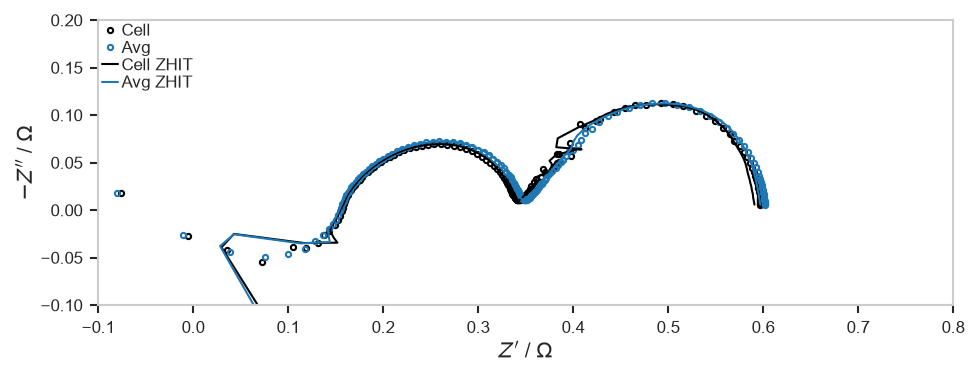

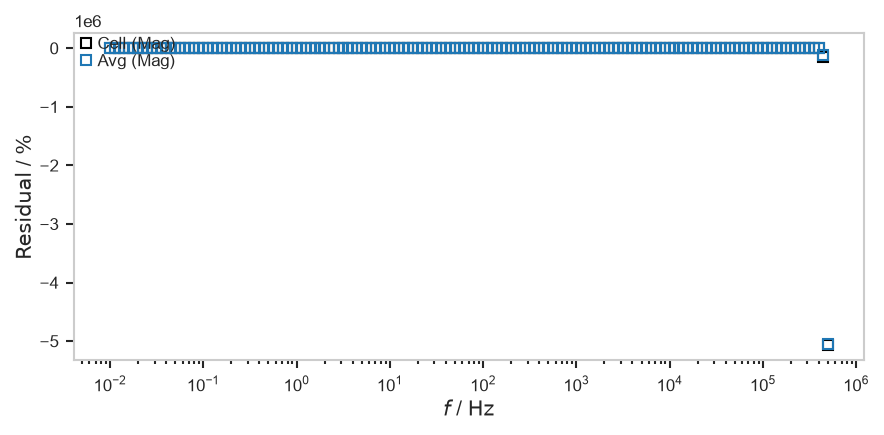

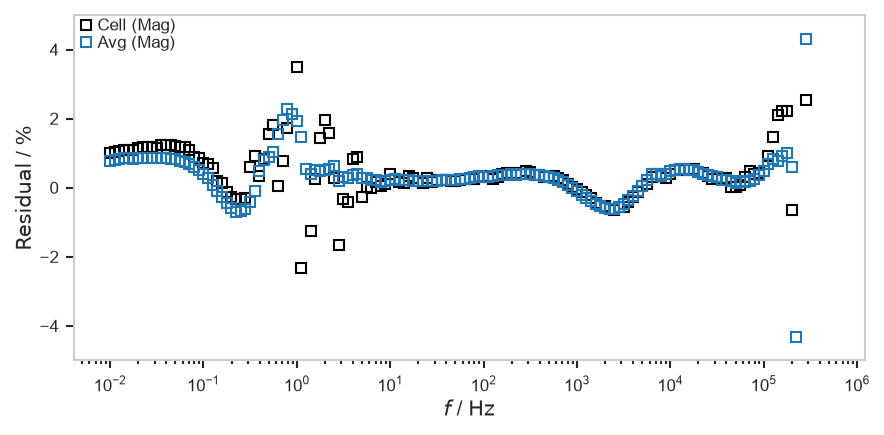

In [4]:

#####################################
##### ZHIT fitting + residuals ######
#####################################
keys_to_consider = ["Cell", "Avg"]  # or any list of keys you want

for key in keys_to_consider:
    entry_dict = eis_plot_dict[key]
    EISData_object = entry_dict["data"]
    data: DataSet = DataSet(frequencies = EISData_object.f, impedances= EISData_object.Z, mask = None, path = "", label = EISData_object.label, uuid = "")
    # important to set center and width to cover frequency range well.
    # default is center = 1.5 and width = 3 (1-1000 Hz)
    # I prefer center 2.5 (10-10,000 Hz) as the region minimally affected by artefacts 
    zhit: ZHITResult = perform_zhit(data, center = 2.5, width = 3.0) 
    EISData_zhit = EISData(zhit.get_impedances(), f = zhit.get_frequencies(), label = f"{EISData_object.label} ZHIT")
    eis_plot_dict[EISData_zhit.label] = {
            "data": EISData_zhit,
            "plot_kwargs": {"color": entry_dict["plot_kwargs"]["color"], "linestyle": "-", "marker": "", "label": EISData_zhit.label},
            "plot": True
        }
    ## show results
    df = zhit.to_statistics_dataframe()
    statistics = df
    display(statistics)
    ## calculate residuals
    observed = EISData_object
    predicted = EISData_zhit
    residuals_plot_dict[EISData_object.label] = {
            "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
            "plot_kwargs": {"color": entry_dict["plot_kwargs"]["color"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
            "plot": True
        }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
NyquistPlot_object.ax.set_ylim(-0.1, 0.2)
NyquistPlot_object.ax.set_xlim(-0.1, 0.8)
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative', Z_rep='polar') # gets a bit misleading for small Z
#ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        if ResidualsPlot_object.Z_rep == 'polar':
            # disable phase plotting
            entry["data"].residuals_phase = None
            entry["data"].residuals_phase_rel = None
            ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)
# ResidualsPlot_object.fig.show() # use with qt, only loads after rest of cell executes so with crops
ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

## Circuit Fitting
Circuit fitting can be achieved using the pyimpspec library.

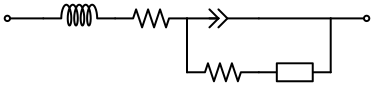

c:\Users\es758\Documents\GitHub\redoxED\.venv\Lib\site-packages\pyimpspec\circuit\warburg.py:155: RuntimeWarning: overflow encountered in tanh
  return (tanh((B * 2 * pi * f * 1j) ** n) / (Y * 2 * pi * f * 1j) ** n).astype(


,Element,Parameter,Value,Std. err. (%),Unit,Fixed
0,L_0,L,2.624293e-08,0.599634,H,No
1,R_1,R,1.445294e-01,0.309937,ohm,No
2,Q_2,Y,1.431164e-03,5.159545,S*s^n,No
3,Q_2,n,7.687456e-01,0.651481,,No
4,R_3,R,1.938846e-01,0.462675,ohm,No
5,Ws_4,B,1.179783e+00,3.072273,s^n,No
6,Ws_4,Y,1.741223e+01,1.599226,S,No
7,Ws_4,n,5.000000e-01,NaN,,Yes


,Label,Value
0,Log pseudo chi-squared,-1.357069
1,Log chi-squared,-4.679256
2,Log chi-squared (reduced),-7.137138
3,Akaike info. criterion,-4824.641652
4,Bayesian info. criterion,-4798.856594
5,Degrees of freedom,287
6,Number of data points,294
7,Number of function evaluations,343
8,Method,least_squares
9,Weight,boukamp


Ohmic: 0.14452937131179755
Activation: 0.19388457033514947
Concentration: 0.2602998279284813


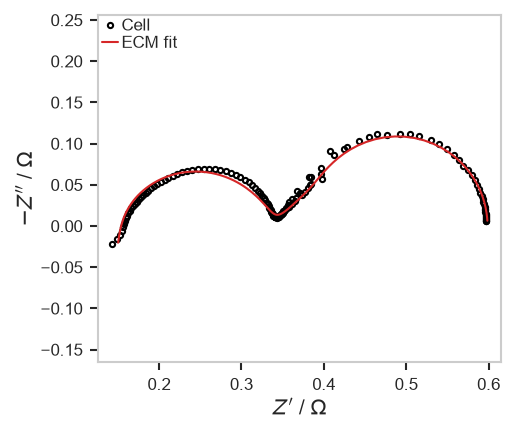

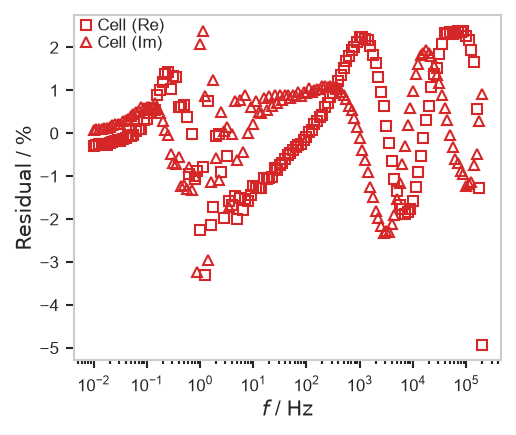

In [ ]:
# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

#########################
##### Data loading ######
#########################

fpath = r"../data/cell_EIS_2.mpr"
# select measurement
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 3) # select 3rd cycle EIS
EISData_object = ECData_object.to_EISData()

#EISData_object.crop_frequency(1e5, 2e5)
EISData_object.label = "Cell"
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

#########################
#### Circuit fitting ####
#########################

# crop as per ZHIT
EISData_object.crop_frequency(0.01, 2e5)
# print(EISData_object.f)
# convert to pyimpspec DataSet for fitting
data: DataSet = DataSet(frequencies = EISData_object.f, impedances= EISData_object.Z, mask = None, path = "", label = EISData_object.label, uuid = "")
# circuit: Circuit = parse_cdc("[LR(Q[RWs])]")
circuit: Circuit = parse_cdc("[LR{R=0.14}(Q[R{R=0.13}Ws{B=1,Y=17, n=0.5f}])]") # f fixes value of n, have really shown this to work out how to put limits on more complicated elements
# circuit: Circuit = parse_cdc("R{R=20f:sol}) # value of 20 fixed and label of sol
# circuit: Circuit = parse_cdc("R{R=20//1e2:sol}) # initial value of 20, no lower limit, 100 uppper limit, and label of sol

## show drawing
drawing: Drawing = circuit.to_drawing(running=True, hide_labels = True)
## Useful other arguments
# hide_labels: bool = False,
# running: bool = False,
# custom_labels: Optional[Dict[Element, str]] = None,
# canvas: Optional[Union[str, "Axes"]] = None,  # noqa: F821
display(drawing)

## perform fit
fit: FitResult = fit_circuit(
  circuit, 
  data,
  method = "least_squares",
  weight = "boukamp",  
  max_nfev=-1, num_procs=-1, timeout=0, constraint_expressions=None, constraint_variables=None)
# fit: FitResult = fit_circuit(circuit, data)

freq_fit, real_resid_percent, imag_resid_percent = fit.get_residuals_data() 
real_z, neg_imag_z = fit.get_nyquist_data(num_per_decade=-1) # default is frequency points used for fit, otherwise can set to make more refined.

EISData_circuit = EISData(Z = real_z - 1j * neg_imag_z, f = freq_fit, label = "ECM fit")
eis_plot_dict[EISData_circuit.label] = {
        "data": EISData_circuit,
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "-", "marker": "", "label": EISData_circuit.label},
        "plot": True
    }

## show results
df: pd.DataFrame = fit.to_parameters_dataframe(running=True) # set true to start from 0
# parameters: str = df.to_markdown(index=False)
parameters = df
df = fit.to_statistics_dataframe()
# statistics: str = df.to_markdown(index=False)
statistics = df
# display(Markdown(parameters))
# display(Markdown(statistics))
display(parameters)
display(statistics)

## extract impedance components
parameters_df = fit.to_parameters_dataframe(running=True)
df = parameters_df

Z_ohm = df.loc[(df["Element"] == "R_1") & (df["Parameter"] == "R"), "Value"].iloc[0]
Z_act = df.loc[(df["Element"] == "R_3") & (df["Parameter"] == "R"), "Value"].iloc[0]

B_value = df.loc[(df["Element"] == "Ws_4") & (df["Parameter"] == "B"), "Value"].iloc[0]
Y_value = df.loc[(df["Element"] == "Ws_4") & (df["Parameter"] == "Y"), "Value"].iloc[0]
n_value = df.loc[(df["Element"] == "Ws_4") & (df["Parameter"] == "n"), "Value"].iloc[0]
Z_conc = (B_value/Y_value)**n_value
Z_tot = Z_ohm + Z_act+ Z_conc

Z_list = [Z_ohm, Z_act, Z_conc]
labels = ['Ohmic', 'Activation', 'Concentration']
color_list = ['cyan', 'yellow', 'indigo']

for i in range(len(Z_list)):
    print(f"{labels[i]}: {Z_list[i]}")
#print(Z_list, labels, color_list)


#########################
### Circuit Residuals ###
#########################

observed = EISData_object
predicted = EISData_circuit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels


###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative') # gets a bit misleading for small Z
#ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)